
# Python for Finance & Credit Risk — Crash Kit (Udemy Intro)
**Goals:**  
- Set up Python environment for finance/credit-risk work  
- Learn essential `pandas` and plotting basics  
- Generate a tiny **loan tape** and perform **descriptive stats**  
- Build a **toy logistic regression** to predict `default_flag`  
- Use clear **Markdown** to guide beginners step-by-step



## 1) Setup & Requirements

You can use either **Anaconda** (recommended for beginners) or **pip + venv**.

**Required libraries:**
- `pandas`, `numpy`
- `matplotlib`
- `scikit-learn` (for the simple model)

> If you're running locally and need to install packages, uncomment and run the next cell.


In [3]:

# OPTIONAL: install packages (uncomment if needed)
# !pip install pandas numpy matplotlib scikit-learn


In [4]:

# Versions (useful for debugging in student Q&A)
import sys, platform
import numpy as np, pandas as pd, matplotlib, sklearn
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.4
OS: Windows-10-10.0.19045-SP0
pandas: 2.2.2
numpy: 1.26.4
matplotlib: 3.8.4
scikit-learn: 1.4.2



## 2) Mini Loan Tape (Synthetic Data)

We create a small, reproducible dataset with typical credit‑risk features:
- `account_id`, `origination_date`, `age`, `income`, `balance`, `credit_limit`, `days_past_due`
- Derived features: `dti` (Debt-to-Income), `util` (Utilization = balance/limit)
- Target: `default_flag` (0/1)


In [6]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 120  # small enough to keep it readable for students

account_id = np.arange(1, n+1)

# Simple date range
dates = pd.date_range("2022-01-01", periods=n, freq="7D")
origination_date = dates[rng.integers(0, len(dates), size=n)]

age = rng.integers(21, 70, size=n)
income = rng.normal(38000, 12000, size=n).clip(12000, 120000)
credit_limit = rng.normal(4500, 2000, size=n).clip(400, 15000)
balance = (credit_limit * rng.uniform(0.05, 1.1, size=n)).clip(0, None)
days_past_due = (rng.integers(0, 90, size=n) * rng.choice([0,1], size=n, p=[0.7,0.3])).astype(int)

# Engineered features
dti = (balance / np.maximum(income/12, 1)).clip(0, 15)  # monthly DTI proxy
util = (balance / np.maximum(credit_limit, 1)).clip(0, 3)  # utilization

# Create a PD-like signal for defaults (logit with some noise)
z = -2.2 + 0.9*(util>0.8) + 0.6*(dti>0.5) + 0.015*(days_past_due) + 0.003*(70-age) + rng.normal(0, 0.5, size=n)
p_default = 1/(1+np.exp(-z))
default_flag = (rng.uniform(0,1,size=n) < p_default).astype(int)

df = pd.DataFrame({
    "account_id": account_id,
    "origination_date": origination_date,
    "age": age,
    "income": income.round(2),
    "credit_limit": credit_limit.round(2),
    "balance": balance.round(2),
    "days_past_due": days_past_due,
    "dti": dti.round(3),
    "util": util.round(3),
    "default_flag": default_flag
})

df.head()


,account_id,origination_date,age,income,credit_limit,balance,days_past_due,dti,util,default_flag
0,1,2022-03-12,42,57221.35,2375.17,1027.03,0,0.215,0.432,0
1,2,2023-10-07,53,35127.73,3441.12,1308.18,58,0.447,0.380,0
2,3,2023-07-01,53,25718.03,2746.28,591.80,0,0.276,0.215,0
3,4,2022-12-31,44,40151.31,4311.47,884.60,0,0.264,0.205,0
4,5,2022-12-24,62,40639.96,984.54,1016.97,0,0.300,1.033,0



## 3) Inspecting the Data

Basic checks that every analyst should do:
- `.shape`, `.head()`, `.info()`
- `.describe()` for numeric summaries


In [8]:

print("Shape:", df.shape)
display(df.head(10))
df.info()
df.describe().T


Shape: (120, 10)


,account_id,origination_date,age,income,credit_limit,balance,days_past_due,dti,util,default_flag
0,1,2022-03-12,42,57221.35,2375.17,1027.03,0,0.215,0.432,0
1,2,2023-10-07,53,35127.73,3441.12,1308.18,58,0.447,0.380,0
2,3,2023-07-01,53,25718.03,2746.28,591.80,0,0.276,0.215,0
3,4,2022-12-31,44,40151.31,4311.47,884.60,0,0.264,0.205,0
4,5,2022-12-24,62,40639.96,984.54,1016.97,0,0.300,1.033,0
5,6,2023-12-23,48,54310.25,1565.91,798.30,0,0.176,0.510,0
6,7,2022-03-12,24,48021.33,8758.49,3963.09,0,0.990,0.452,0
7,8,2023-08-05,58,42282.45,1925.15,1571.25,0,0.446,0.816,1
8,9,2022-06-18,49,55559.63,2306.43,1454.53,0,0.314,0.631,0
9,10,2022-03-19,52,23734.84,8173.83,8443.13,0,4.269,1.033,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   account_id        120 non-null    int32         
 1   origination_date  120 non-null    datetime64[ns]
 2   age               120 non-null    int64         
 3   income            120 non-null    float64       
 4   credit_limit      120 non-null    float64       
 5   balance           120 non-null    float64       
 6   days_past_due     120 non-null    int32         
 7   dti               120 non-null    float64       
 8   util              120 non-null    float64       
 9   default_flag      120 non-null    int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(1)
memory usage: 8.1 KB


,count,mean,min,25%,50%,75%,max,std
account_id,120.0,60.5,1.0,30.75,60.5,90.25,120.0,34.785054
origination_date,120,2023-03-10 11:24:00,2022-01-01 00:00:00,2022-08-25 06:00:00,2023-03-11 00:00:00,2023-10-07 00:00:00,2024-03-30 00:00:00,NaN
age,120.0,45.025,21.0,34.75,45.0,56.0,69.0,13.265525
income,120.0,37892.035333,12232.53,28999.42,36443.425,44748.495,72966.35,12143.25381
credit_limit,120.0,4635.790083,400.0,3348.03,4724.6,5971.5975,10310.13,2029.551845
balance,120.0,2631.852833,136.79,999.1575,2159.105,3872.965,8962.77,2035.236559
days_past_due,120.0,16.6,0.0,0.0,0.0,35.75,86.0,26.7605
dti,120.0,0.988225,0.046,0.3105,0.6495,1.2125,6.368,1.03528
util,120.0,0.572575,0.056,0.27475,0.582,0.82375,1.099,0.313994
default_flag,120.0,0.25,0.0,0.0,0.0,0.25,1.0,0.434828



## 4) Custom Descriptive Summary

Quick, business-friendly aggregates:
- Overall default rate
- Default rate by utilization bucket
- Default rate by days past due bucket


In [10]:

# Overall default rate
overall_dr = df["default_flag"].mean()
print(f"Overall default rate: {overall_dr:.2%}")

# Utilization buckets
util_bins = pd.cut(df["util"], bins=[-0.01, 0.3, 0.6, 0.9, 1.2, 3.0], labels=["<=0.3","(0.3,0.6]","(0.6,0.9]","(0.9,1.2]","(1.2,3.0]"])
util_summary = df.groupby(util_bins, observed=False)["default_flag"].agg(["count","mean"]).rename(columns={"mean":"default_rate"})
display(util_summary)

# DPD buckets
dpd_bins = pd.cut(df["days_past_due"], bins=[-1,0,30,60,120], labels=["0","1-30","31-60","61-120"])
dpd_summary = df.groupby(dpd_bins, observed=False)["default_flag"].agg(["count","mean"]).rename(columns={"mean":"default_rate"})
display(dpd_summary)


Overall default rate: 25.00%


,count,default_rate
util,,
<=0.3,33,0.060606
"(0.3,0.6]",28,0.178571
"(0.6,0.9]",37,0.297297
"(0.9,1.2]",22,0.545455
"(1.2,3.0]",0,NaN


,count,default_rate
days_past_due,,
0,78,0.205128
1-30,10,0.300000
31-60,17,0.411765
61-120,15,0.266667



## 5) Visualizations (Matplotlib)

We’ll keep one chart per cell to keep it clear and re-usable for slides.


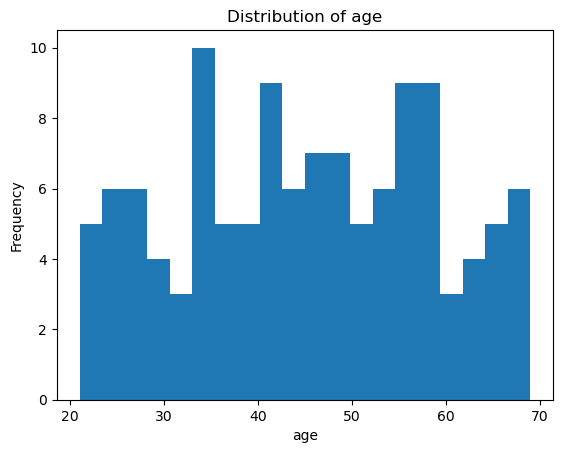

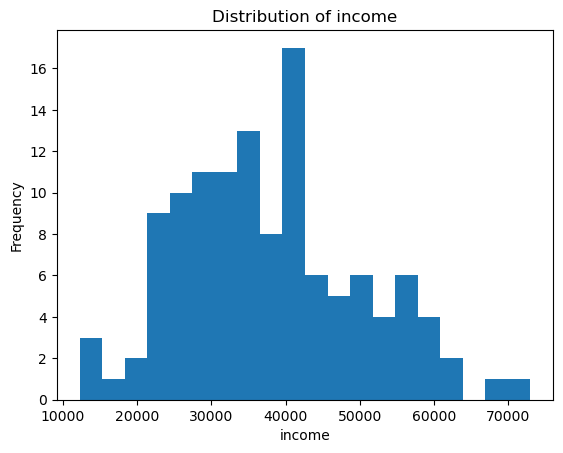

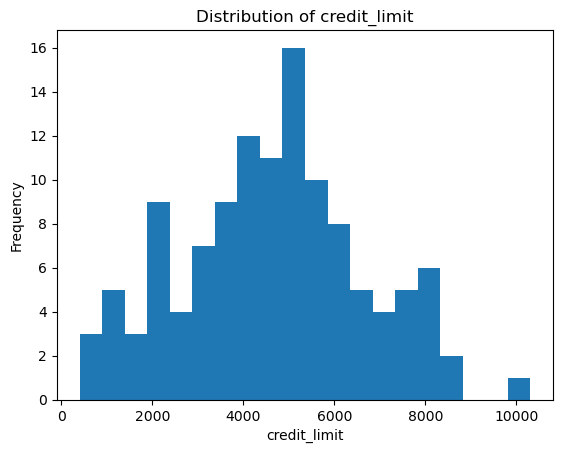

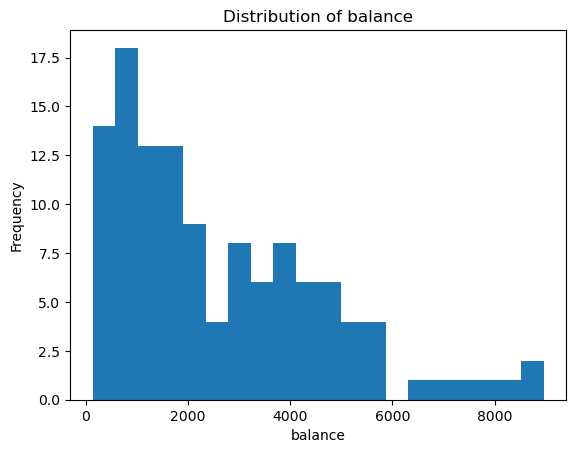

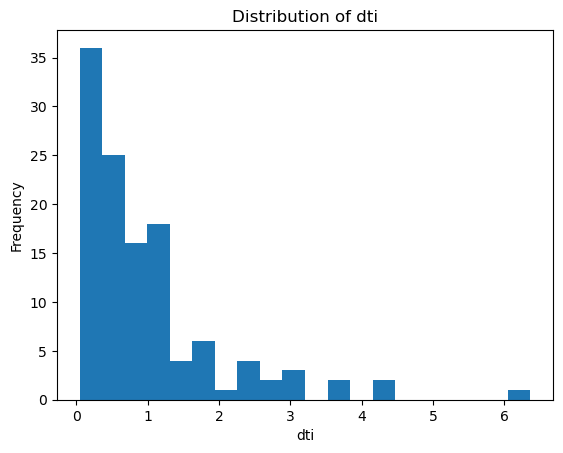

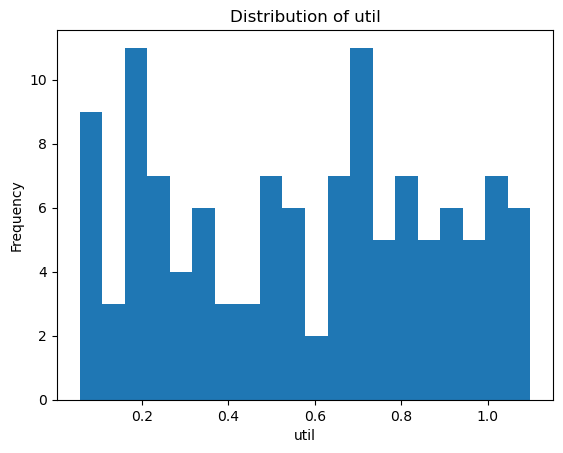

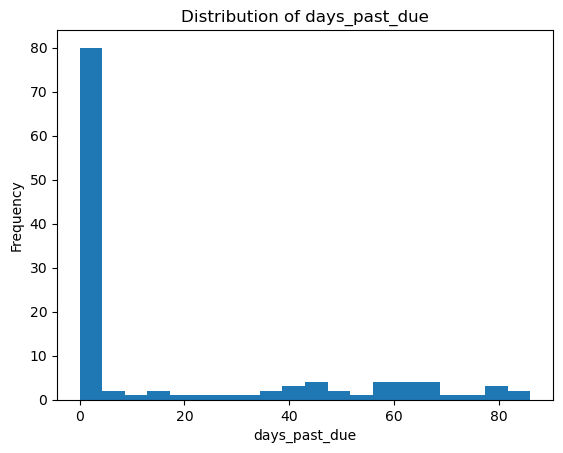

In [12]:

# Histogram: numeric distributions
import matplotlib.pyplot as plt

numeric_cols = ["age","income","credit_limit","balance","dti","util","days_past_due"]
for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


<Figure size 640x480 with 0 Axes>

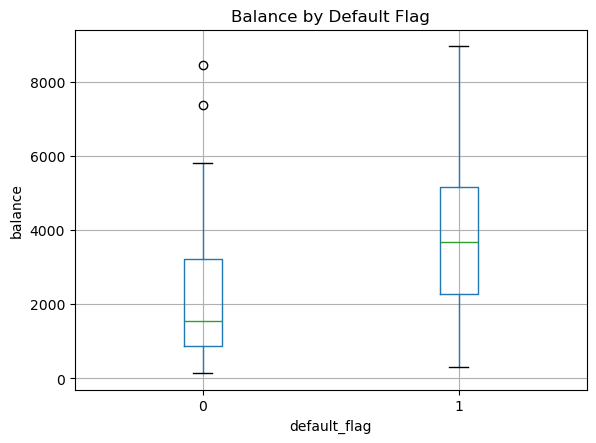

In [13]:

# Boxplot: balance by default flag
import matplotlib.pyplot as plt

plt.figure()
df.boxplot(column="balance", by="default_flag")
plt.title("Balance by Default Flag")
plt.suptitle("")
plt.xlabel("default_flag")
plt.ylabel("balance")
plt.show()


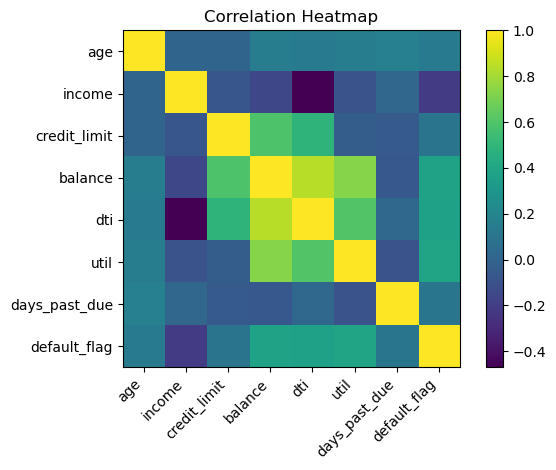

In [14]:

# Correlation matrix
import numpy as np
import matplotlib.pyplot as plt

corr = df[numeric_cols + ["default_flag"]].corr()
plt.figure()
plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()


In [15]:
# --- Utilization buckets + summary (clean naming) ---
import pandas as pd

util_bins = pd.cut(
    df["util"],
    bins=[-0.01, 0.3, 0.6, 0.9, 1.2, 3.0],
    labels=["<=0.3","(0.3,0.6]","(0.6,0.9]","(0.9,1.2]","(1.2,3.0]"]
)
util_bins.name = "util_bucket"  # <-- give the index a name

util_summary = (
    df.groupby(util_bins, observed=False)["default_flag"]
      .agg(["count","mean"])
      .rename(columns={"mean":"default_rate"})
)

util_plot = util_summary.reset_index()  # has "util_bucket" column
util_plot


,util_bucket,count,default_rate
0,<=0.3,33,0.060606
1,"(0.3,0.6]",28,0.178571
2,"(0.6,0.9]",37,0.297297
3,"(0.9,1.2]",22,0.545455
4,"(1.2,3.0]",0,NaN


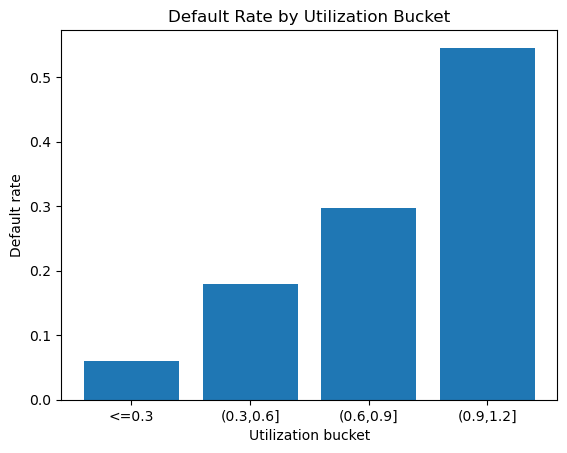

In [16]:
# --- Bar plot: default rate by utilization bucket ---
import matplotlib.pyplot as plt

plt.figure()
plt.bar(util_plot["util_bucket"].astype(str), util_plot["default_rate"])
plt.title("Default Rate by Utilization Bucket")
plt.xlabel("Utilization bucket")
plt.ylabel("Default rate")
plt.xticks(rotation=0)
plt.show()



## 6) Tiny Predictive Model (Logistic Regression)

> Educational demo only — not a production IFRS 9 model.

Steps:
1. Select features (`age`, `income`, `util`, `dti`, `days_past_due`)
2. Train/test split
3. Fit `LogisticRegression`
4. Report accuracy, confusion matrix, and AUC/ROC curve


Accuracy: 0.7333
Confusion matrix:
 [[21  2]
 [ 6  1]]
AUC: 0.7826


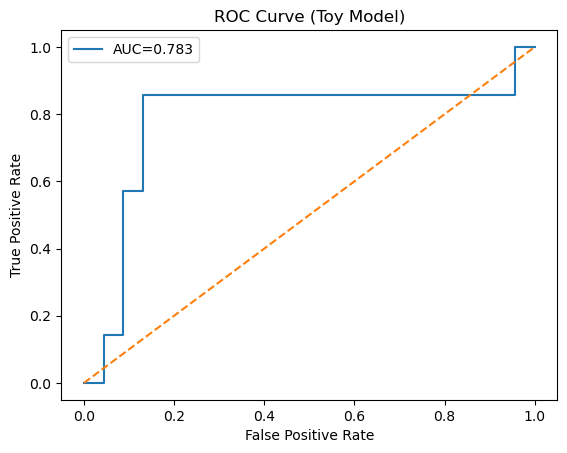

In [18]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

X = df[["age","income","util","dti","days_past_due"]].copy()
y = df["default_flag"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(acc, 4))
print("Confusion matrix:\n", cm)
print("AUC:", round(auc, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve (Toy Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()



## 7) Next Steps (for Udemy)

- Add short **quizzes** after each section (Basics, Descriptives, Model)
- Export charts as images for slides
- Optional: save `df` and predictions for later modules (IFRS 9 PIT PD & ECL)


In [20]:

# OPTIONAL: save dataset for later modules
# df.to_csv("mini_loan_tape.csv", index=False)
# print("Saved mini_loan_tape.csv")
